<a href="https://colab.research.google.com/github/feridehmedovv200/OIBSIP/blob/main/L2_Task3_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== CLASS IMBALANCE ANALYSIS ===
Total Transactions: 10,000
Legitimate Transactions (Class 0): 9,849 (98.49%)
Fraudulent Transactions (Class 1): 151 (1.51%)



/tmp/ipykernel_3169/3514052673.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amount', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_3169/3514052673.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])


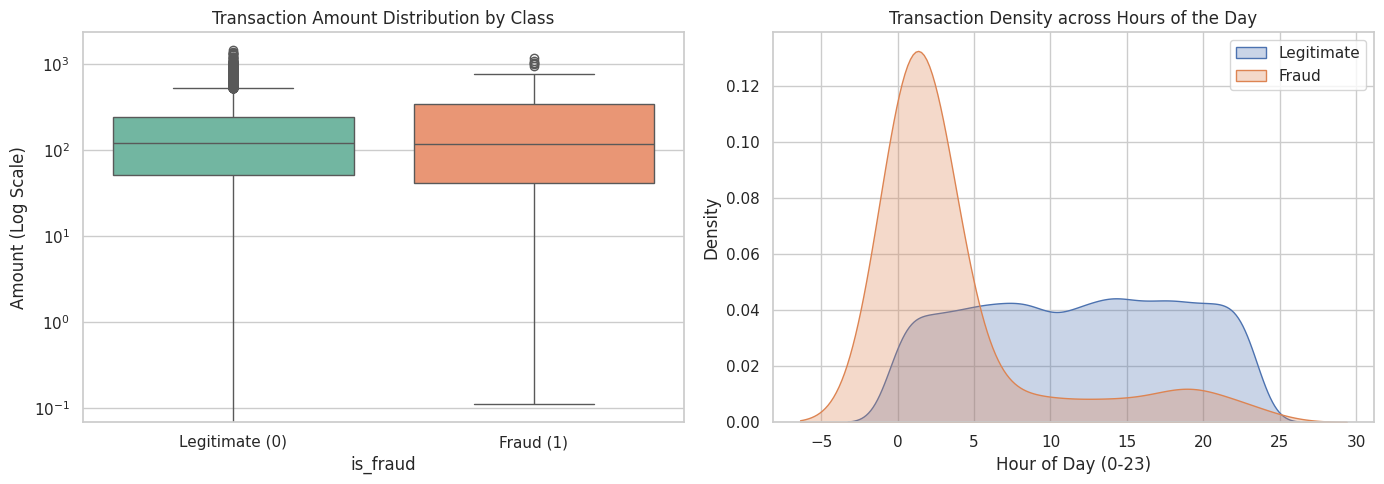

=== Logistic Regression ===
Precision: 0.2566 | Recall: 0.9667 | F1-Score: 0.4056 | AUC-ROC: 0.9932
Confusion Matrix:
[[1886   84]
 [   1   29]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9574    0.9780      1970
           1     0.2566    0.9667    0.4056        30

    accuracy                         0.9575      2000
   macro avg     0.6281    0.9620    0.6918      2000
weighted avg     0.9883    0.9575    0.9694      2000

--------------------------------------------------
=== Random Forest ===
Precision: 1.0000 | Recall: 0.4333 | F1-Score: 0.6047 | AUC-ROC: 1.0000
Confusion Matrix:
[[1970    0]
 [  17   13]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9914    1.0000    0.9957      1970
           1     1.0000    0.4333    0.6047        30

    accuracy                         0.9915      2000
   macro avg     0.9957    0.7167    0.8002      2000
weighted avg     0

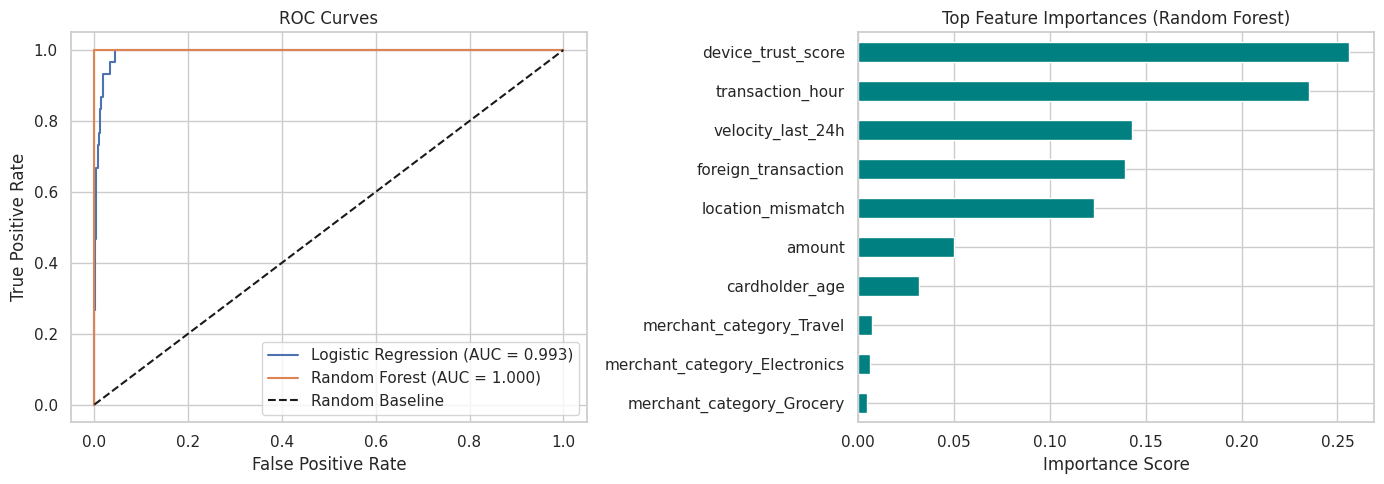

=== LOGISTIC REGRESSION COEFFICIENTS ===
Top Positive Drivers for Fraud:
velocity_last_24h                2.373594
location_mismatch                2.090685
foreign_transaction              2.084602
amount                           1.131792
merchant_category_Electronics    1.056178
dtype: float64

Top Negative Drivers (Reduces Fraud Probability):
merchant_category_Food      0.843271
merchant_category_Travel    0.548969
cardholder_age             -0.825049
transaction_hour           -3.083837
device_trust_score         -3.534884
dtype: float64


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Qrafiklərin stilini təyin edirik
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. LOAD DATASET & ANALYSE CLASS IMBALANCE
# ==============================================================================
df = pd.read_csv('credit_card_fraud_10k.csv')

total_tx = len(df)
fraud_count = df['is_fraud'].sum()
non_fraud_count = total_tx - fraud_count
fraud_pct = (fraud_count / total_tx) * 100

print("=== CLASS IMBALANCE ANALYSIS ===")
print(f"Total Transactions: {total_tx:,}")
print(f"Legitimate Transactions (Class 0): {non_fraud_count:,} ({100 - fraud_pct:.2f}%)")
print(f"Fraudulent Transactions (Class 1): {fraud_count:,} ({fraud_pct:.2f}%)\n")

# ==============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Transaction Amounts
sns.boxplot(x='is_fraud', y='amount', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Transaction Amount Distribution by Class')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[0].set_yscale('log')
axes[0].set_ylabel('Amount (Log Scale)')

# Time-of-day Analysis
sns.kdeplot(data=df[df['is_fraud'] == 0], x='transaction_hour', ax=axes[1], label='Legitimate', common_norm=False, fill=True, alpha=0.3)
sns.kdeplot(data=df[df['is_fraud'] == 1], x='transaction_hour', ax=axes[1], label='Fraud', common_norm=False, fill=True, alpha=0.3)
axes[1].set_title('Transaction Density across Hours of the Day')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. PREPROCESSING & STRATIFIED TRAIN/TEST SPLIT
# ==============================================================================
X = df.drop(columns=['transaction_id', 'is_fraud'])
y = df['is_fraud']

categorical_cols = ['merchant_category']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Stratified split vasitəsilə fraud nisbətinin həm Train, həm də Test dəstlərində eyni saxlanılması
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Sütun adlarını çıxarırıq
cat_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
feature_names = numeric_cols + cat_feature_names

# ==============================================================================
# 4. MODEL TRAINING (Class Weight Balancing & Models)
# ==============================================================================
# Model 1: Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_prep, y_train)

y_pred_lr = lr_model.predict(X_test_prep)
y_proba_lr = lr_model.predict_proba(X_test_prep)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_prep, y_train)

y_pred_rf = rf_model.predict(X_test_prep)
y_proba_rf = rf_model.predict_proba(X_test_prep)[:, 1]

# ==============================================================================
# 5. MODEL EVALUATION
# ==============================================================================
def print_evaluation_metrics(name, y_true, y_pred, y_proba):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"=== {name} ===")
    print(f"Precision: {p:.4f} | Recall: {r:.4f} | F1-Score: {f1:.4f} | AUC-ROC: {auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    print("-" * 50)

print_evaluation_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
print_evaluation_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf)

# Plot ROC Curves & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# Feature Importances (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top Feature Importances (Random Forest)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. COEFFICIENT ANALYSIS
# ==============================================================================
lr_coefs = pd.Series(lr_model.coef_[0], index=feature_names).sort_values(ascending=False)
print("=== LOGISTIC REGRESSION COEFFICIENTS ===")
print("Top Positive Drivers for Fraud:")
print(lr_coefs.head(5))
print("\nTop Negative Drivers (Reduces Fraud Probability):")
print(lr_coefs.tail(5))